<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install opendatasets

In [7]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadtegarbijanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 156MB/s]


In [10]:
import os
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [11]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:

                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


In [12]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


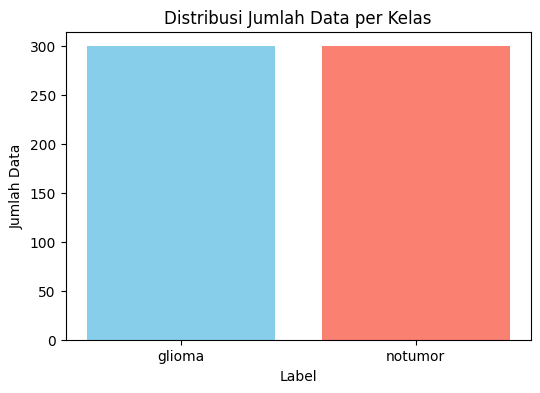

In [13]:
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

##

In [17]:
def median(image, rowkernel, columnkernel):
    row, column = int(rowkernel/2), int(columnkernel/2)
    image_pad = np.pad(image, [(row, row), (column, column)], mode="edge")
    result = np.zeros(image.shape)

    for i in range(row, image.shape[0] + row):
        for j in range(column, image.shape[1] + column):
            submatrix = image_pad[i-row:i+row+1, j-column:j+column+1]
            result[i-row, j-column] = np.median(submatrix)

    return result.astype(np.uint8)

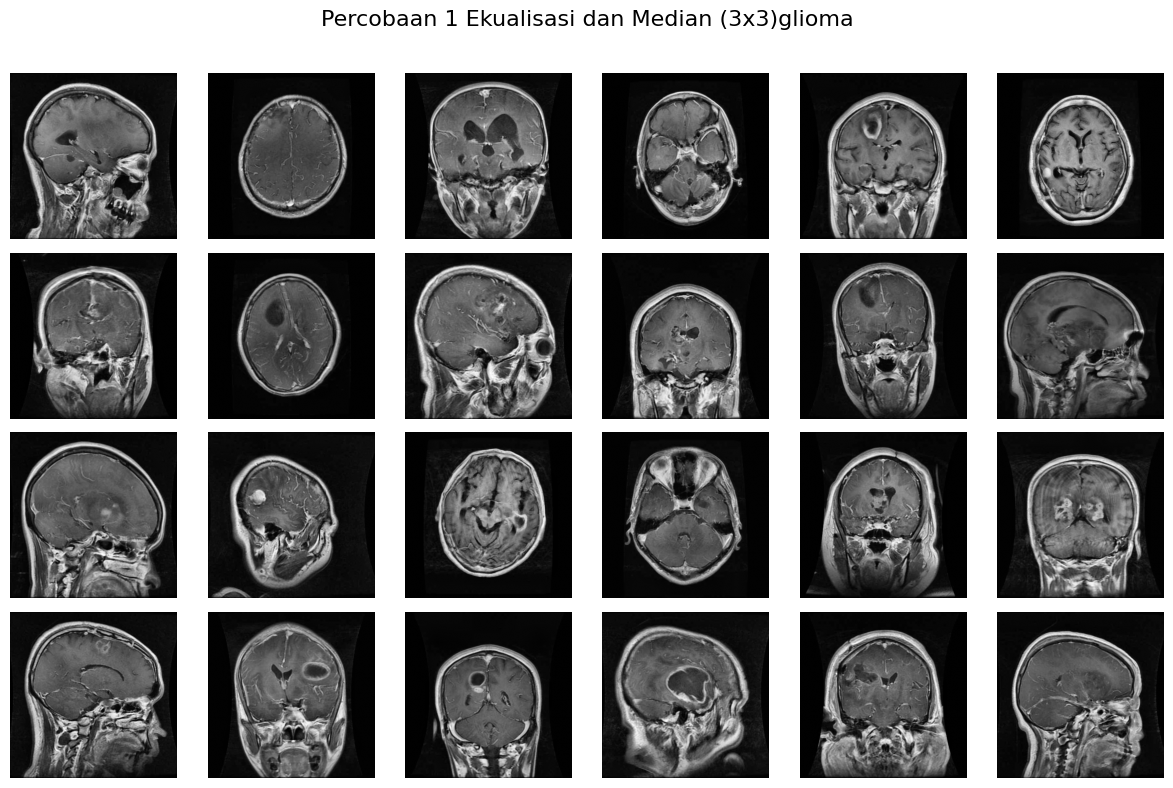

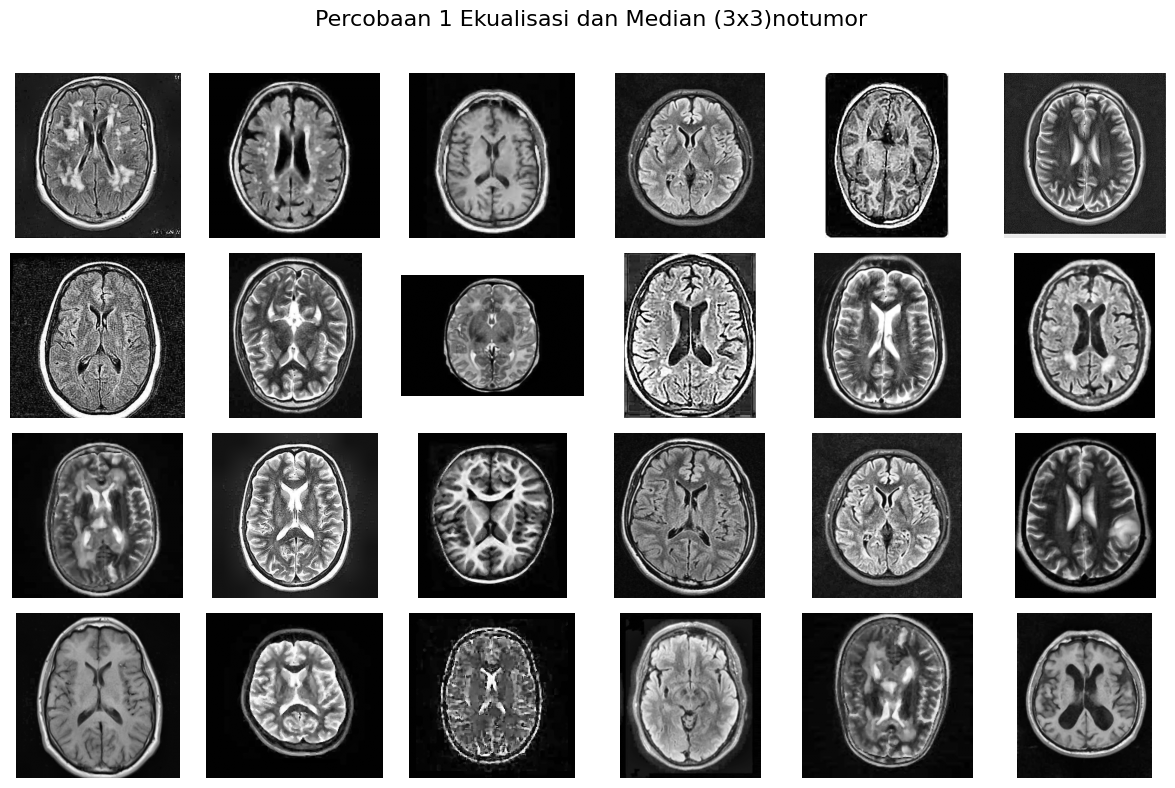

In [18]:
def percobaan1(img):
    clahe = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8))

    equalized = clahe.apply(img)
    img_equal = median(equalized, 3, 3)
    return img_equal

dataPreprocessed = [percobaan1(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]

    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 1 Ekualisasi dan Median (3x3){label}', fontsize=16)

    for k in range(24):
        plt.subplot(4, 6, k + 1)
        plt.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

In [19]:
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

print(len(dataPreprocessed))
# for i in range(len(X_data)): # Loop through each image and do preprocessing

600


In [20]:
def glcm(img, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(img, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [21]:

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [22]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [23]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [24]:

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)


for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)


In [30]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
from google.colab import files
files.download('hasil_ekstraksi_2.csv')

display(hasilEkstrak)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,gl-0511.jpg,glioma,82.588808,152.856274,80.095921,150.656933,0.484972,0.421515,0.493009,0.419889,...,0.007242,0.005911,0.084371,0.076863,0.085098,0.076883,0.986842,0.975640,0.987240,0.975991
1,gl-0216.jpg,glioma,35.980935,65.886359,31.831634,60.724293,0.727367,0.687113,0.734683,0.689466,...,0.116523,0.112869,0.340260,0.335884,0.341355,0.335959,0.990985,0.983506,0.992025,0.984798
2,gl-0030.jpg,glioma,90.789376,130.451063,61.224690,155.930844,0.550584,0.497909,0.549793,0.493229,...,0.047118,0.045444,0.215696,0.213199,0.217067,0.213176,0.985736,0.979507,0.990382,0.975504
3,gl-0647.jpg,glioma,63.762888,114.830171,60.622917,116.875261,0.672942,0.638727,0.688774,0.638862,...,0.107803,0.104738,0.326575,0.323724,0.328333,0.323633,0.989111,0.980409,0.989648,0.980060
4,gl-1374.jpg,glioma,88.015250,143.680210,64.575641,144.541144,0.560883,0.517660,0.587420,0.515415,...,0.031871,0.029792,0.176801,0.172490,0.178524,0.172605,0.988301,0.980907,0.991418,0.980793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,no-0289.jpg,notumor,1134.422103,1732.831314,769.742440,1742.124860,0.575781,0.505258,0.566015,0.506340,...,0.139974,0.135885,0.378647,0.368220,0.374132,0.368626,0.907979,0.858034,0.938135,0.857276
596,no-1644.jpg,notumor,250.765942,400.246376,208.251017,411.944553,0.526170,0.436261,0.502281,0.435316,...,0.015607,0.014177,0.137051,0.118727,0.124929,0.119067,0.961870,0.939204,0.968337,0.937427
597,no-1398.jpg,notumor,370.917620,559.179608,264.620567,559.390087,0.403916,0.332150,0.416262,0.333680,...,0.003873,0.003066,0.062085,0.054455,0.062237,0.055371,0.942991,0.913980,0.959324,0.913948
598,no-0443.jpg,notumor,84.461361,138.143420,63.251590,136.845491,0.299936,0.256310,0.353552,0.258209,...,0.000816,0.000482,0.024757,0.021837,0.028559,0.021950,0.970402,0.951424,0.977780,0.951880


<Axes: >

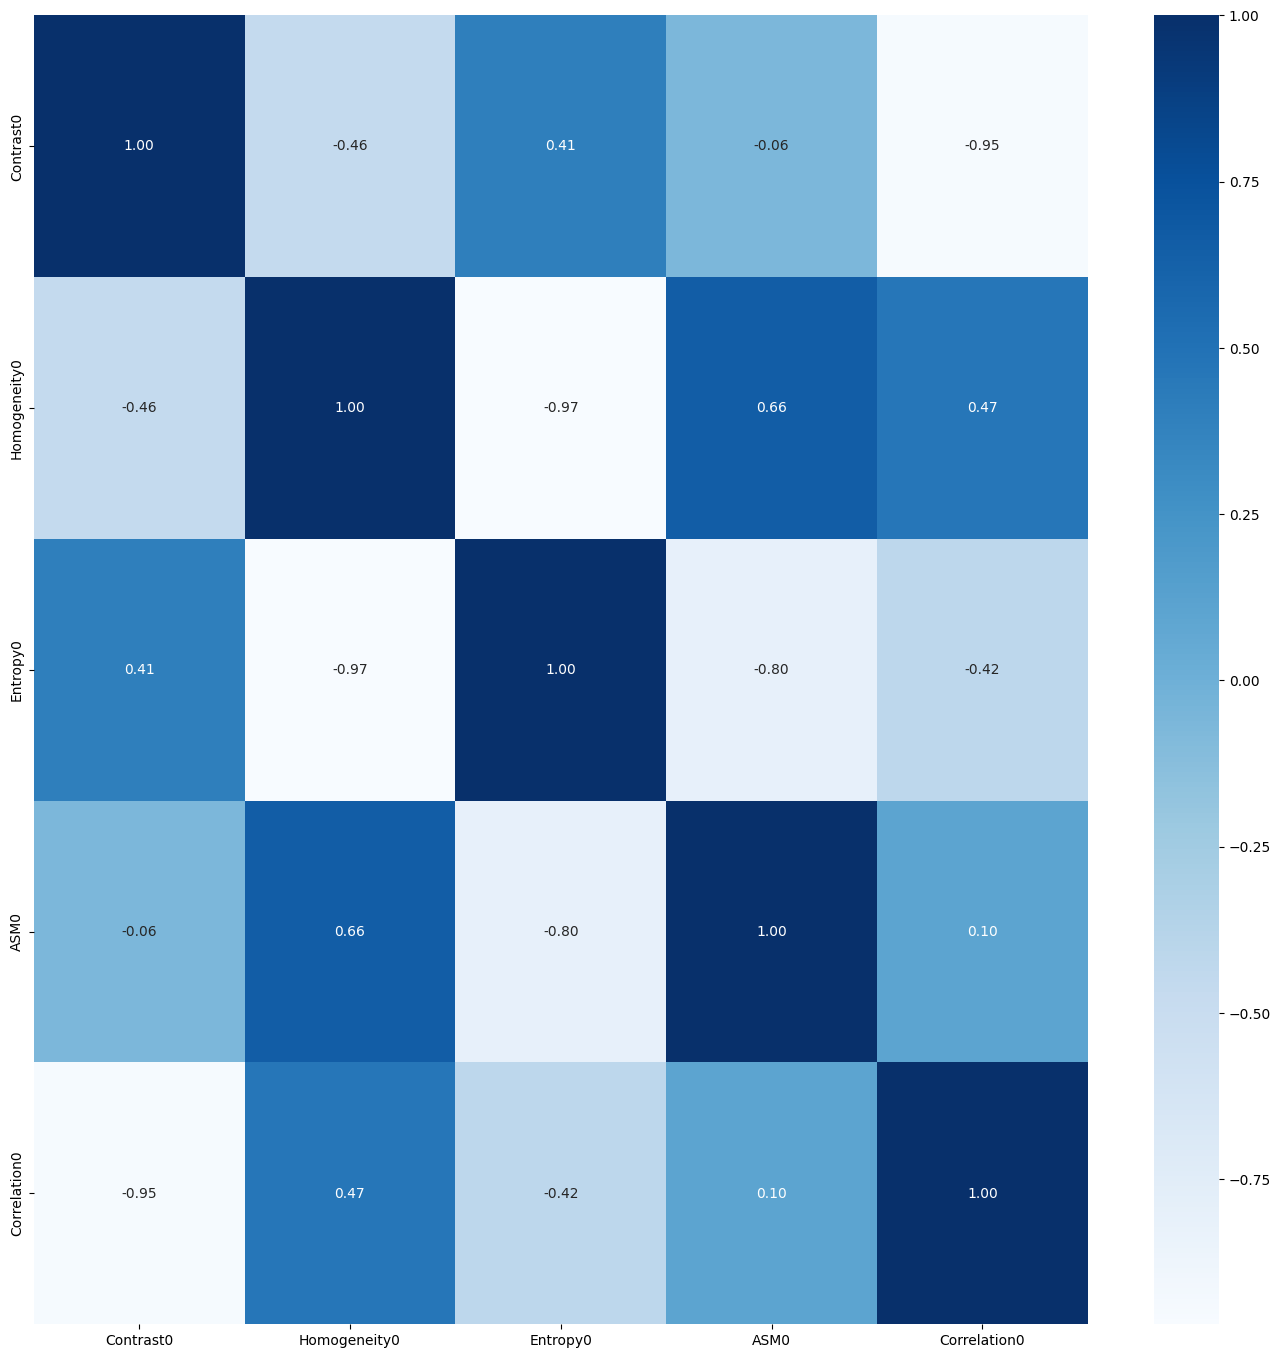

In [31]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(480, 5)
(120, 5)


In [33]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [34]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [35]:

# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       238
     notumor       0.99      0.99      0.99       242

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480

[[236   2]
 [  3 239]]
Accuracy: 0.9895833333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.92      0.98      0.95        62
     notumor       0.98      0.91      0.95        58

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120

[[61  1]
 [ 5 53]]
Accuracy: 0.95


In [36]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.93      1.00      0.96       238
     notumor       1.00      0.92      0.96       242

    accuracy                           0.96       480
   macro avg       0.96      0.96      0.96       480
weighted avg       0.96      0.96      0.96       480

[[237   1]
 [ 19 223]]
Accuracy: 0.9583333333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.90      0.98      0.94        62
     notumor       0.98      0.88      0.93        58

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.93      0.93       120

[[61  1]
 [ 7 51]]
Accuracy: 0.9333333333333333


In [37]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.95      1.00      0.97       238
     notumor       1.00      0.95      0.97       242

    accuracy                           0.97       480
   macro avg       0.97      0.97      0.97       480
weighted avg       0.97      0.97      0.97       480

[[238   0]
 [ 13 229]]
Accuracy: 0.9729166666666667

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.91      1.00      0.95        62
     notumor       1.00      0.90      0.95        58

    accuracy                           0.95       120
   macro avg       0.96      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120

[[62  0]
 [ 6 52]]
Accuracy: 0.95


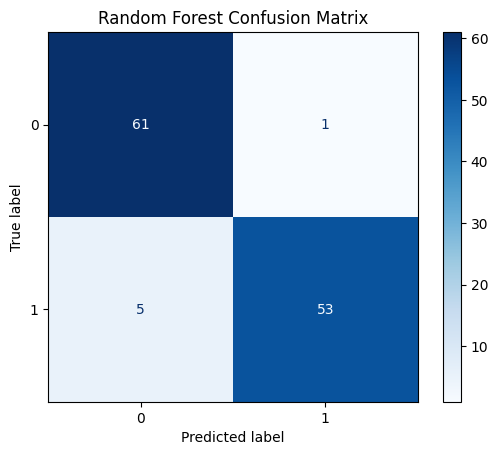

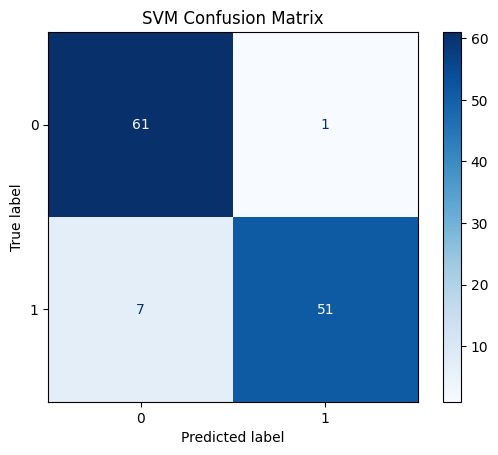

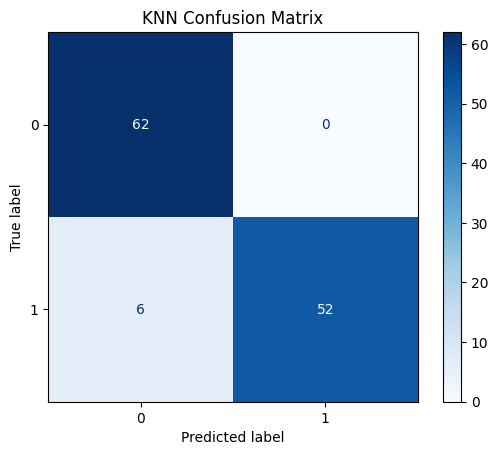

In [38]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")